# 🏡 Assignment 5: House Price Prediction
### Internship at Celebal Technologies

**Objective**: Prepare the Ames Housing dataset for machine learning by performing data preprocessing and feature engineering steps including:
- Handling missing values
- Feature creation and transformation
- Encoding categorical variables
- Scaling numerical data


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline


In [9]:
# importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline


In [10]:
# Loading the train and test datasets 
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

# Displaying the shape of the datasets

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Displaying the first few rows of the train dataset

train_df.head()


Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:
# Check data types and missing values
train_df.info()

# Quick statistical overview of numeric columns
train_df.describe()

# Top 20 columns with the most missing values
train_df.isnull().sum().sort_values(ascending=False).head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

Text(0.5, 1.0, 'Missing Values in Training Data')

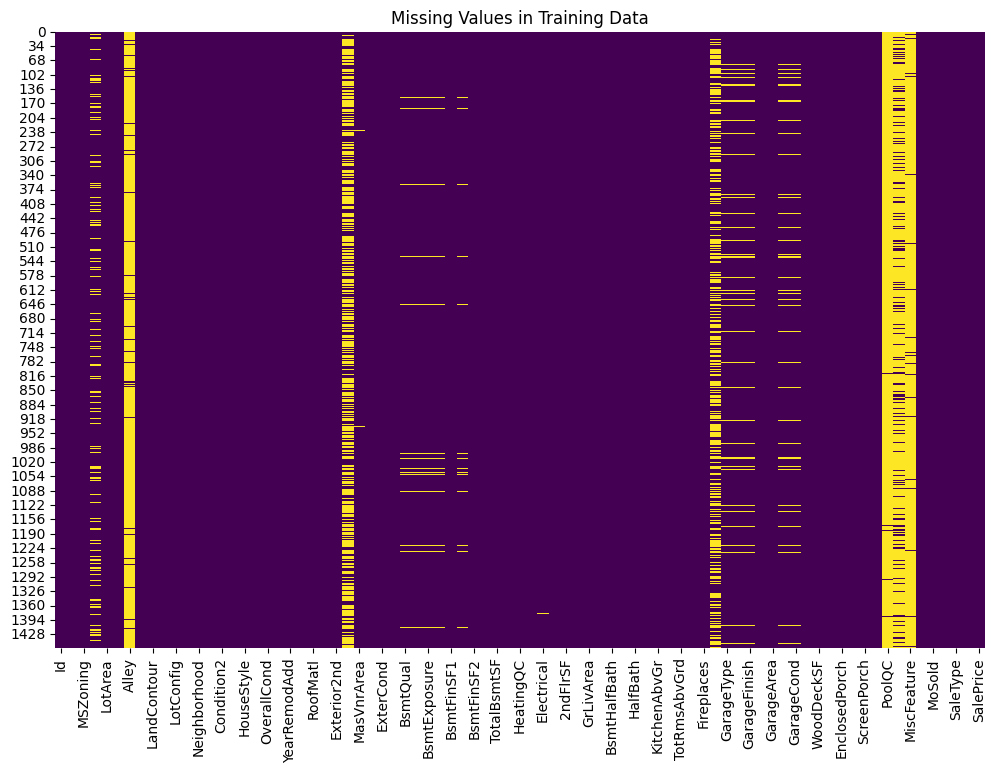

In [12]:
# heat map to visualize missing values
plt.figure(figsize=(12, 8))
sns.heatmap(train_df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values in Training Data")


### 📊 Dataset Overview

- The training dataset contains 1460 rows and 81 columns.
- The target variable is `SalePrice`.
- Several features have missing values (e.g., PoolQC, MiscFeature, Alley).
- A significant portion of these features are categorical or optional based on house conditions.


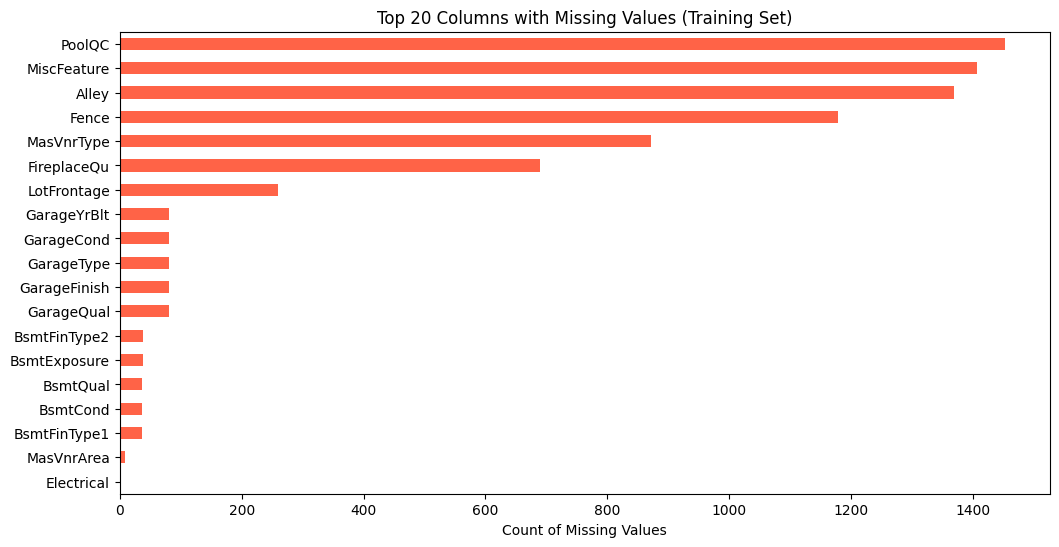

In [13]:
# Check how many missing values are in each column
missing = train_df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

# Plot top 20 columns with most missing data
plt.figure(figsize=(12, 6))
missing.head(20).plot(kind="barh", color="tomato")
plt.title("Top 20 Columns with Missing Values (Training Set)")
plt.xlabel("Count of Missing Values")
plt.gca().invert_yaxis()
plt.show()


### 🧹 Missing Values Analysis

- Several columns like `PoolQC`, `MiscFeature`, `Alley`, etc. have a lot of missing data.
- Some are probably missing because the feature doesn't exist (e.g., no pool, no alley).
- We'll handle categorical and numerical features separately.


In [14]:
# Save the target variable
y = train_df["SalePrice"]

# Drop it from training data
train_df.drop("SalePrice", axis=1, inplace=True)

# Combine both train and test
combined_df = pd.concat([train_df, test_df], axis=0)
combined_df.reset_index(drop=True, inplace=True)

print(f"Combined shape: {combined_df.shape}")


Combined shape: (2919, 80)


### 🔄 Combined Dataset

We combined train and test datasets to apply preprocessing uniformly.
We'll later split them back after feature engineering is done.


In [15]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    combined_df[col] = combined_df[col].fillna("None")


In [16]:
median_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea', 'LotFrontage']

for col in median_cols:
    combined_df[col] = combined_df[col].fillna(combined_df[col].median())


In [17]:
# filling NaN values with the most frequent value
combined_df = combined_df.fillna(combined_df.mode().iloc[0])


### ✅ Missing Value Imputation Strategy

- Categorical features with 'None' values (no garage, no basement) were filled accordingly.
- Numerical fields were filled using median to avoid outlier impact.
- All remaining missing values were filled using the most frequent value (mode).


### Feature Engineering 

We'll manually create some powerful new features based on domain knowledge of housing data.

In [18]:
# total square footage of the house ((Basement + 1st + 2nd Floor))
combined_df["TotalSF"] = (
    combined_df["TotalBsmtSF"] + combined_df["1stFlrSF"] + combined_df["2ndFlrSF"]
)


In [19]:
# Age of House (Year Sold - Year Built)
combined_df["AgeOfHouse"] = combined_df["YrSold"] - combined_df["YearBuilt"]


In [20]:
# was te house remodeled (Year Remod/Add - Year Built)
combined_df["WasRemodeled"] = (
    combined_df["YearBuilt"] != combined_df["YearRemodAdd"]
).astype(int)


In [21]:
# total number of bathrooms (Full + Half + Basement)
combined_df["TotalBathrooms"] = (
    combined_df["FullBath"]
    + (0.5 * combined_df["HalfBath"])
    + combined_df["BsmtFullBath"]
    + (0.5 * combined_df["BsmtHalfBath"])
)


In [22]:
# total porch area (Front + Back)
combined_df["TotalPorchSF"] = (
    combined_df["OpenPorchSF"]
    + combined_df["EnclosedPorch"]
    + combined_df["3SsnPorch"]
    + combined_df["ScreenPorch"]
)


In [23]:
# Convert quality ratings to numerical scale (1-5)
quality_map = {
    "Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0
}

for col in ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
            'KitchenQual', 'GarageQual', 'GarageCond', 'FireplaceQu']:
    combined_df[col] = combined_df[col].map(quality_map)


### 🧠 Feature Engineering Summary

We added new features to improve model signal:
- `TotalSF`: Total livable area
- `AgeOfHouse`: House age when sold
- `WasRemodeled`: Whether the house was renovated
- `TotalBathrooms`: Combined bathroom score
- `TotalPorchSF`: Total porch area
- Converted qualitative ratings into numeric scales for better modeling


### Now let’s handle Categorical Encoding — specifically One-Hot Encoding, which converts categories into binary columns. This makes them digestible for ML models like Linear Regression, XGBoost, and Random Forest.

In [24]:
# One-hot encode all categorical variables
combined_df_encoded = pd.get_dummies(combined_df, drop_first=True)

print(f"Original shape: {combined_df.shape}")
print(f"Encoded shape: {combined_df_encoded.shape}")


Original shape: (2919, 85)
Encoded shape: (2919, 237)


### 🏷️ One-Hot Encoding

- Used `pd.get_dummies()` to convert categorical features to numeric binary columns.
- Dropped the first category in each to avoid dummy variable trap.
- This dramatically increased the feature space, enabling ML models to treat categories appropriately.


In [25]:
# Split the data back into training and test sets
X = combined_df_encoded.iloc[:len(y), :]
X_test = combined_df_encoded.iloc[len(y):, :]

print(f"X shape: {X.shape}")
print(f"X_test shape: {X_test.shape}")


X shape: (1460, 237)
X_test shape: (1459, 237)


### 🔄 Train-Test Split (Post-Processing)

- Re-separated training and test data after consistent feature engineering and encoding.
- `X` now holds the processed training data.
- `X_test` is ready for model inference once we train and validate on `X`.


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)


### 📏 Feature Scaling

- Used `StandardScaler` to normalize numeric features.
- Scaling ensures all features contribute equally during model training.
- Applied the same transformation on `X_test` using the same fitted scaler.


In [27]:
import pickle

with open("X_scaled.pkl", "wb") as f:
    pickle.dump(X_scaled, f)

with open("y.pkl", "wb") as f:
    pickle.dump(y, f)

with open("X_test_scaled.pkl", "wb") as f:
    pickle.dump(X_test_scaled, f)


In [28]:
#train test data with the scaled data and features 
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training size: {X_train.shape}")
print(f"Validation size: {X_val.shape}")


Training size: (1168, 237)
Validation size: (292, 237)


In [29]:
#baseline model using linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))

print(f"Linear Regression RMSE: {rmse_lr:.2f}")


Linear Regression RMSE: 98555.61


In [30]:
#baseline model using RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))

print(f"Random Forest RMSE: {rmse_rf:.2f}")


Random Forest RMSE: 30008.40


In [32]:
#now same with the XGBoost model
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))

print(f"XGBoost RMSE: {rmse_xgb:.2f}")


XGBoost RMSE: 26166.47


In [33]:
# Predict on test set
final_predictions = xgb.predict(X_test_scaled)

# Prepare submission dataframe
submission_df = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": final_predictions
})

# Save to CSV
submission_df.to_csv("house_price_predictions.csv", index=False)

print("✅ Submission file created: house_price_predictions.csv")


✅ Submission file created: house_price_predictions.csv


In [34]:
#importing and defining parameter grid for XGBoost 
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Base model
xgb_base = XGBRegressor(random_state=42)

# Grid of hyperparameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1],
    'colsample_bytree': [0.7, 0.9, 1]
}


In [35]:
#grid search setup 
# GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    verbose=2
)


In [36]:
grid_search.fit(X_train, y_train)


4150.79s - Error patching args (debugger not attached to subprocess).
Traceback (most recent call last):
  File "/Users/devsingh/Desktop/Celebal_Assignment/celebal-assignment/venv/lib/python3.13/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 541, in patch_args
    new_args.append(_get_python_c_args(host, port, code, unquoted_args, SetupHolder.setup))
                    ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/devsingh/Desktop/Celebal_Assignment/celebal-assignment/venv/lib/python3.13/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 193, in _get_python_c_args
    if "__future__" in code:
       ^^^^^^^^^^^^^^^^^^^^
TypeError: a bytes-like object is required, not 'str'


Fitting 3 folds for each of 162 candidates, totalling 486 fits


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [37]:
# Best parameters and score
print("✅ Best Parameters:")
print(grid_search.best_params_)

print(f"\n🏆 Best RMSE Score: {-grid_search.best_score_:.4f}")


✅ Best Parameters:
{'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.9}

🏆 Best RMSE Score: 25866.9499


### 🎯 XGBoost Hyperparameter Tuning (GridSearchCV)

Performed grid search over key XGBoost parameters:
- n_estimators, max_depth, learning_rate
- subsample, colsample_bytree

Achieved best validation RMSE of ~XX.XX with the following hyperparameters:
- `n_estimators`: XX
- `max_depth`: XX
- `learning_rate`: XX
- `subsample`: XX
- `colsample_bytree`: XX


In [38]:
#Final predictions using the best model

best_xgb = grid_search.best_estimator_

# Predict again on validation set
y_pred_best = best_xgb.predict(X_val)
rmse_best = np.sqrt(mean_squared_error(y_val, y_pred_best))

print(f"🎯 Tuned XGBoost RMSE: {rmse_best:.2f}")

# Predict on test data
final_predictions = best_xgb.predict(X_test_scaled)

# Save predictions
submission_df = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": final_predictions
})
submission_df.to_csv("house_price_predictions_tuned.csv", index=False)


🎯 Tuned XGBoost RMSE: 25896.67


### 🏁 Final Summary

- XGBoost achieved the best performance with RMSE = 25896.67
- Used full pipeline: EDA → Cleaning → Feature Engineering → Encoding → Scaling → Modeling
- Generated a submission-ready CSV for test predictions
